# Airline Operating Metrics — Data Explorer
Explore `raw/` and `processed/` datasets interactively.

In [1]:
import glob
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.4f}'.format)

# ── Load all raw CSVs ──────────────────────────────────────────────────────
raw = pd.concat(
    [pd.read_csv(f) for f in sorted(glob.glob('raw/*.csv'))],
    ignore_index=True
)

# Coerce types
raw['value'] = pd.to_numeric(raw['value'], errors='coerce')
raw['year']  = raw['year'].astype(int)

# ── Load processed CSVs ───────────────────────────────────────────────────
colombia = pd.read_csv('processed/colombia_market_share.csv')
colombia['value'] = pd.to_numeric(colombia['value'], errors='coerce')

print(f'raw/:       {len(raw):,} rows across {raw["airline"].nunique()} airlines')
print(f'processed/: {len(colombia):,} rows (colombia_market_share)')

raw/:       470 rows across 8 airlines
processed/: 116 rows (colombia_market_share)


---
## 1. Coverage Overview
What years, quarters, and metrics do we have per airline?

In [2]:
# Row counts and non-null value counts per airline
summary = (
    raw.groupby('airline')
       .agg(
           rows=('metric', 'count'),
           filled=('value', 'count'),
           metrics=('metric', 'nunique'),
           years=('year', lambda x: sorted(x.unique())),
           quarters=('quarter', lambda x: sorted(x.unique())),
       )
)
summary

,rows,filled,metrics,years,quarters
airline,,,,,
AMERICAN,60,46,30,"[2024, 2025]",[FY]
AVIANCA,58,53,30,"[2024, 2025]",[FY]
COPA,58,53,30,"[2024, 2025]",[FY]
DELTA,60,48,30,"[2024, 2025]",[FY]
JETBLUE,58,36,30,"[2024, 2025]",[FY]
LATAM,58,53,30,"[2024, 2025]",[FY]
SOUTHWEST,58,38,30,"[2024, 2025]",[FY]
UNITED,60,48,30,"[2024, 2025]",[FY]


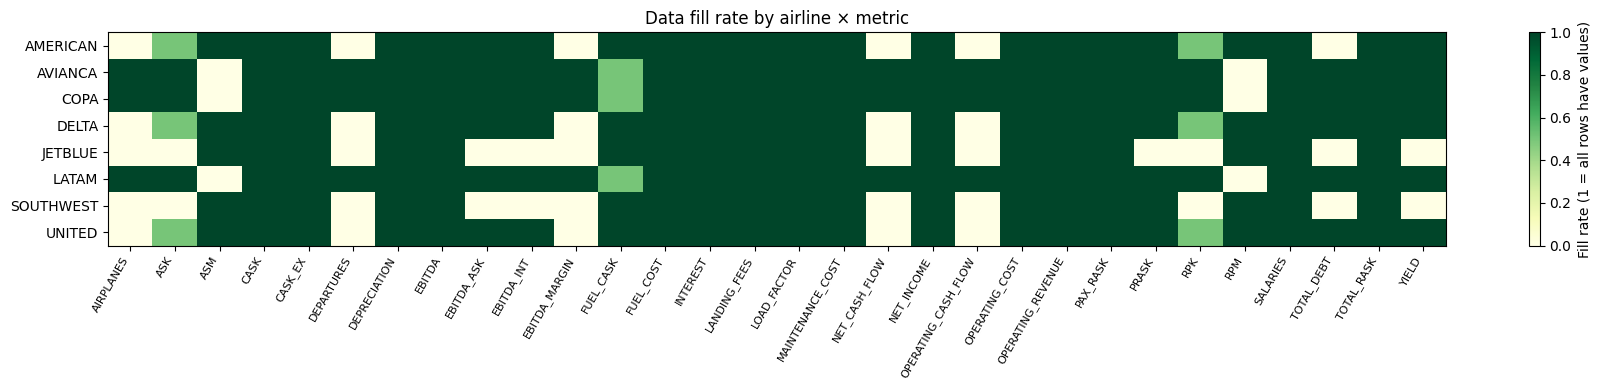

In [3]:
# Heatmap: which (airline, metric) cells have data?
fill_rate = (
    raw.groupby(['airline', 'metric'])['value']
       .apply(lambda s: s.notna().sum() / len(s))
       .unstack('metric')
       .fillna(0)
)

try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    fig, ax = plt.subplots(figsize=(18, 4))
    im = ax.imshow(fill_rate.values, aspect='auto', cmap='YlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(fill_rate.columns)))
    ax.set_xticklabels(fill_rate.columns, rotation=60, ha='right', fontsize=8)
    ax.set_yticks(range(len(fill_rate.index)))
    ax.set_yticklabels(fill_rate.index)
    plt.colorbar(im, ax=ax, label='Fill rate (1 = all rows have values)')
    ax.set_title('Data fill rate by airline × metric')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed — showing table instead')
    display(fill_rate.style.background_gradient(cmap='YlGn', axis=None))

In [4]:
# Spine consistency check: which (year, quarter, metric) combos are missing per airline?
all_combos = set(zip(raw['year'], raw['quarter'], raw['metric']))
print(f'Total unique (year, quarter, metric) combinations in dataset: {len(all_combos)}\n')

for airline in sorted(raw['airline'].unique()):
    sub = raw[raw['airline'] == airline]
    existing = set(zip(sub['year'], sub['quarter'], sub['metric']))
    missing  = all_combos - existing
    tag = f'{len(missing):3d} missing' if missing else '   spine OK'
    print(f'  {airline:<12} {tag}')

Total unique (year, quarter, metric) combinations in dataset: 58

  AMERICAN        spine OK
  AVIANCA         spine OK
  COPA            spine OK
  DELTA           spine OK
  JETBLUE         spine OK
  LATAM           spine OK
  SOUTHWEST       spine OK
  UNITED          spine OK


---
## 2. Single-Airline Explorer
Set `AIRLINE` and `YEAR` to slice into one carrier.

In [5]:
AIRLINE = 'COPA'    # change to any airline code
YEAR    = 2024      # change to any year present in the data

sub = raw[(raw['airline'] == AIRLINE) & (raw['year'] == YEAR)]

# Wide pivot: rows = quarter, cols = metric
wide = sub.pivot_table(
    index='quarter',
    columns='metric',
    values='value',
    aggfunc='last'   # last row wins (handles corrections)
)

print(f'{AIRLINE} — {YEAR}')
wide

COPA — 2024


metric,AIRPLANES,ASK,CASK,CASK_EX,DEPARTURES,DEPRECIATION,EBITDA,EBITDA_MARGIN,FUEL_COST,INTEREST,...,OPERATING_CASH_FLOW,OPERATING_COST,OPERATING_REVENUE,PAX_RASK,PRASK,RPK,SALARIES,TOTAL_DEBT,TOTAL_RASK,YIELD
quarter,,,,,,,,,,,,,,,,,,,,,
FY,109.0000,"48,123.0000",5.6000,3.6200,"146,607.0000","330,710.0000","1,083,662.0000",0.3145,"949,309.0000","-84,493.0000",...,"969,729.0000","2,693,247.0000","3,446,199.0000",6.8400,1.5600,"41,546.0000","470,644.0000","552,335.0000",7.1600,7.9300


In [6]:
# Full detail: all rows for this airline/year including source and unit
(
    sub[['year','quarter','metric','value','unit','source']]
      .sort_values(['quarter','metric'])
      .reset_index(drop=True)
)

,year,quarter,metric,value,unit,source
0,2024,FY,AIRPLANES,109.0000,units,Image4-Avianca-LATAM-Copa-FY
1,2024,FY,ASK,"48,123.0000",millions,Image4-Avianca-LATAM-Copa-FY
2,2024,FY,ASM,NaN,thousands,Image4-Avianca-LATAM-Copa-FY
3,2024,FY,CASK,5.6000,usd_per_ask,Image4-Avianca-LATAM-Copa-FY
4,2024,FY,CASK_EX,3.6200,usd_per_ask,Image4-Avianca-LATAM-Copa-FY
5,2024,FY,DEPARTURES,"146,607.0000",units,Image4-Avianca-LATAM-Copa-FY
6,2024,FY,DEPRECIATION,"330,710.0000",thousands_USD,Image4-Avianca-LATAM-Copa-FY
7,2024,FY,EBITDA,"1,083,662.0000",thousands_USD,Image4-Avianca-LATAM-Copa-FY
8,2024,FY,EBITDA_MARGIN,0.3145,decimal,Image4-Avianca-LATAM-Copa-FY
9,2024,FY,FUEL_CASK,NaN,usd_per_ask,Image4-Avianca-LATAM-Copa-FY


---
## 3. Cross-Carrier Metric Comparison
Compare one metric across all airlines for a given year/quarter.

In [ ]:
METRIC  = 'CASK'
QUARTER = 'FY'

comp = (
    raw[
        (raw['metric']  == METRIC) &
        (raw['quarter'] == QUARTER)
    ]
    .pivot_table(index='year', columns='airline', values='value', aggfunc='last')
    .sort_index()
)

print(f'{METRIC}  |  {QUARTER}  (check unit column before cross-carrier math!)\n')
# Show units alongside
units_used = (
    raw[(raw['metric'] == METRIC) & (raw['quarter'] == QUARTER)]
    .groupby('airline')['unit'].first()
)
print('Units per airline:')
print(units_used.to_string())
print()
comp

In [ ]:
# Bar chart for the most recent year available
try:
    import matplotlib.pyplot as plt
    latest = comp.dropna(how='all').index.max()
    row = comp.loc[latest].dropna().sort_values()

    fig, ax = plt.subplots(figsize=(10, 4))
    row.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{METRIC} — {QUARTER} {latest}')
    ax.set_ylabel(f'{METRIC} (see unit note above)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed')

---
## 4. Time-Series for One Metric, One Airline

,year,quarter,value,unit,source
0,2024,FY,0.8140,decimal,Image4-Avianca-LATAM-Copa-FY
1,2025,FY,0.7960,decimal,Image4-Avianca-LATAM-Copa-FY


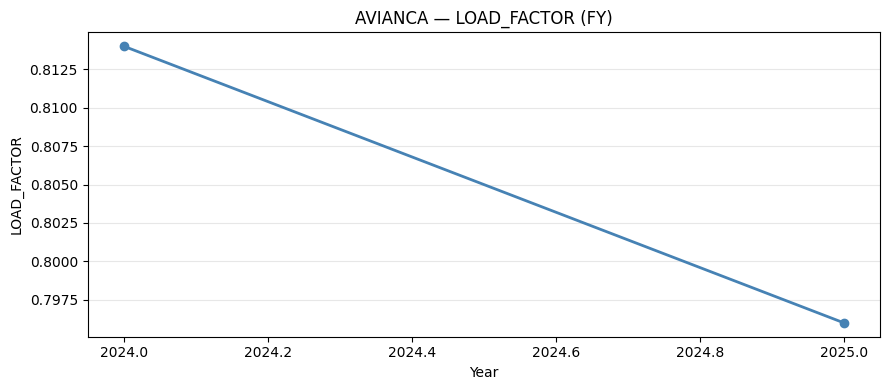

In [7]:
TS_AIRLINE = 'AVIANCA'
TS_METRIC  = 'LOAD_FACTOR'
TS_QUARTER = 'FY'        # set to None to include all quarters

ts = raw[(raw['airline'] == TS_AIRLINE) & (raw['metric'] == TS_METRIC)]
if TS_QUARTER:
    ts = ts[ts['quarter'] == TS_QUARTER]

ts = ts.sort_values('year')[['year','quarter','value','unit','source']]
display(ts.reset_index(drop=True))

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ts['year'], ts['value'], marker='o', linewidth=2, color='steelblue')
    ax.set_title(f'{TS_AIRLINE} — {TS_METRIC} ({TS_QUARTER or "all quarters"})')
    ax.set_xlabel('Year')
    ax.set_ylabel(TS_METRIC)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed')

---
## 5. Unit-Safe LatAm vs US Cost Comparison
Filter to comparable unit groups before doing any arithmetic.

In [8]:
COST_METRIC  = 'CASK'
COST_QUARTER = 'FY'

us = raw[
    (raw['metric']  == COST_METRIC) &
    (raw['quarter'] == COST_QUARTER) &
    (raw['unit']    == 'cents_per_ask')
].pivot_table(index='year', columns='airline', values='value', aggfunc='last')

latam = raw[
    (raw['metric']  == COST_METRIC) &
    (raw['quarter'] == COST_QUARTER) &
    (raw['unit']    == 'usd_per_ask')
].pivot_table(index='year', columns='airline', values='value', aggfunc='last')

print(f'── US carriers  ({COST_METRIC}, cents_per_ask) ──')
display(us)
print(f'\n── LatAm carriers  ({COST_METRIC}, usd_per_ask) ──')
display(latam)

── US carriers  (CASK, cents_per_ask) ──


airline,AMERICAN,DELTA,JETBLUE,SOUTHWEST,UNITED
year,,,,,
2024,17.6400,19.3200,15.4200,15.3400,19.1100
2025,17.6100,19.1100,15.3300,15.3600,16.3400



── LatAm carriers  (CASK, usd_per_ask) ──


airline,AVIANCA,COPA,LATAM
year,,,
2024,7.0200,5.6000,7.2000
2025,6.9600,5.4000,7.1100


---
## 6. Colombia Market Share (processed/)

In [ ]:
colombia

In [ ]:
# Pivot: market share by airline and period
mkt_share = (
    colombia[colombia['metric'] == 'market_share']
    .pivot_table(
        index=['market', 'period', 'year'],
        columns='airline',
        values='value',
        aggfunc='last'
    )
    .sort_index()
)
print('Colombia market share (decimal = fraction of passengers)')
mkt_share

In [ ]:
# YoY pax change
yoy = (
    colombia[colombia['metric'] == 'pax_yoy_change']
    .pivot_table(
        index=['market', 'period', 'year'],
        columns='airline',
        values='value',
        aggfunc='last'
    )
    .sort_index()
)
print('Colombia YoY pax change (decimal = fraction)')
yoy

---
## 7. Raw Data Browser
Free-form filter to inspect any slice of the raw dataset.

In [ ]:
# Edit these filters (set to None to skip that filter)
FILTER_AIRLINE = None          # e.g. 'COPA'
FILTER_METRIC  = 'EBITDA'     # e.g. 'LOAD_FACTOR'
FILTER_YEAR    = None          # e.g. 2024
FILTER_QUARTER = None          # e.g. 'FY'

mask = pd.Series([True] * len(raw))
if FILTER_AIRLINE: mask &= raw['airline'] == FILTER_AIRLINE
if FILTER_METRIC:  mask &= raw['metric']  == FILTER_METRIC
if FILTER_YEAR:    mask &= raw['year']    == FILTER_YEAR
if FILTER_QUARTER: mask &= raw['quarter'] == FILTER_QUARTER

result = raw[mask].sort_values(['airline','year','quarter']).reset_index(drop=True)
print(f'{len(result)} rows matched')
result